In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install -q transformers torch sklearn matplotlib seaborn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
# Pip aur setuptools ko pehle upgrade karein taake metadata error na aaye
!pip install --upgrade pip setuptools wheel

# 'sklearn' ki bajaye 'scikit-learn' install karein
!pip install -q transformers torch scikit-learn matplotlib seaborn

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training ESM Transformer...
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.

   TRANSFORMER (ESM-2) RESULTS
Accuracy: 96.88%
MCC: 0.94
F1-Score: 96.58%
Precision: 95.64%
Sensitivity (Recall): 97.53%
Specificity: 96.33%
Confusion Matrix:
[[473  18]
 [ 10 395]]


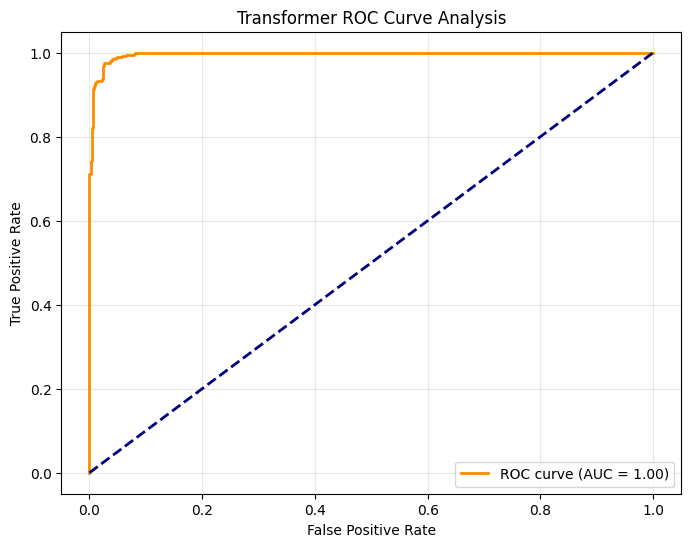

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

# 1. Device Setup (GPU check)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Dataset Loading Function
def parse_fasta(path):
    seqs = []
    with open(path, 'r') as f:
        current = ""
        for line in f:
            if line.startswith(">"):
                if current: seqs.append(current)
                current = ""
            else: current += line.strip()
        if current: seqs.append(current)
    return seqs

# Files upload honi chahiye: '0.6thermo.fasta' aur '0.6 non thermo.fasta'
thermo_seqs = parse_fasta('/content/0.6thermo.fasta')
non_thermo_seqs = parse_fasta('/content/0.6 non thermo.fasta')

X = thermo_seqs + non_thermo_seqs
y = [1]*len(thermo_seqs) + [0]*len(non_thermo_seqs)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ESM Tokenizer & Dataset
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ProteinDataset(Dataset):
    def __init__(self, seqs, labels):
        self.labels = labels
        self.encodings = tokenizer(seqs, padding=True, truncation=True, max_length=512, return_tensors="pt")
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

train_loader = DataLoader(ProteinDataset(X_train, y_train), batch_size=8, shuffle=True)
test_loader = DataLoader(ProteinDataset(X_test, y_test), batch_size=8)

# 4. ESM Transformer Model
class ESMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.esm = EsmModel.from_pretrained(model_name)
        self.classifier = nn.Linear(320, 1) # 320 for 8M model
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state.mean(dim=1) # Mean pooling
        return self.sigmoid(self.classifier(pooled_output))

model = ESMClassifier().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.BCELoss()

# 5. Training Loop
print("Training ESM Transformer...")
for epoch in range(5): # Fine-tuning for 5 epochs
    model.train()
    for batch in train_loader:
        input_ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, mask).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

# 6. Evaluation & Results
model.eval()
y_probs, y_true = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids, mask = batch['input_ids'].to(device), batch['attention_mask'].to(device)
        outputs = model(input_ids, mask).squeeze()
        y_probs.extend(outputs.cpu().numpy())
        y_true.extend(batch['labels'].numpy())

y_pred = (np.array(y_probs) > 0.5).astype(int)

# --- Metrics Analysis ---
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

print("\n" + "="*30)
print("   TRANSFORMER (ESM-2) RESULTS")
print("="*30)
print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"MCC: {matthews_corrcoef(y_true, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_true, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_true, y_pred)*100:.2f}%")
print(f"Sensitivity (Recall): {recall_score(y_true, y_pred)*100:.2f}%")
print(f"Specificity: {(cm[0,0]/(cm[0,0]+cm[0,1]))*100:.2f}%")
print(f"Confusion Matrix:\n{cm}")

# 7. ROC Curve Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Transformer ROC Curve Analysis')
plt.legend(loc="lower right")
plt.show()

Self-Consistency Test

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training transformer_self-consistency ...
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.

   TRANSFORMER_SELF-CONSISTENCY RESULTS
Accuracy: 96.540178571%
MCC: 0.930752978
F1-Score: 96.233292831%
Precision: 94.736842105%
Sensitivity (Recall): 97.777777778%
Specificity: 95.519348269%
Confusion Matrix:
[[469  22]
 [  9 396]]

Model saved as transformer_self-consistency.pth


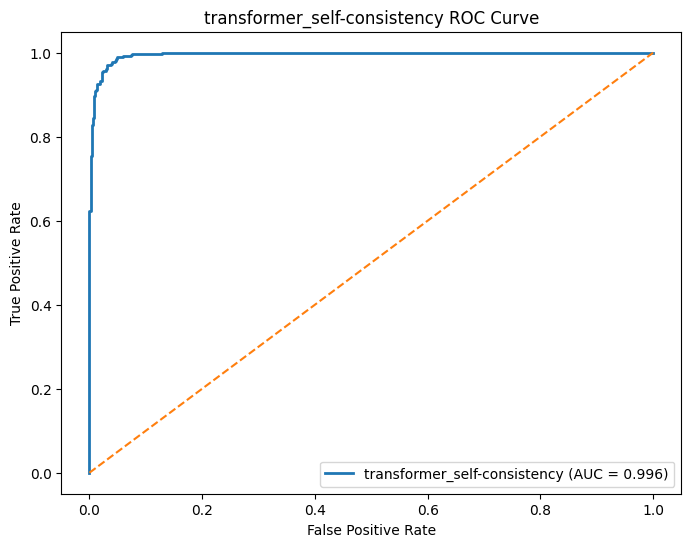

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

# 🔥 Custom Model Name
MODEL_NAME_TAG = "transformer_self-consistency"

# 1. Device Setup (GPU check)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Dataset Loading Function
def parse_fasta(path):
    seqs = []
    with open(path, 'r') as f:
        current = ""
        for line in f:
            if line.startswith(">"):
                if current: seqs.append(current)
                current = ""
            else: current += line.strip()
        if current: seqs.append(current)
    return seqs

# Load files
thermo_seqs = parse_fasta('/content/0.6thermo.fasta')
non_thermo_seqs = parse_fasta('/content/0.6 non thermo.fasta')

X = thermo_seqs + non_thermo_seqs
y = [1]*len(thermo_seqs) + [0]*len(non_thermo_seqs)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Tokenizer
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ProteinDataset(Dataset):
    def __init__(self, seqs, labels):
        self.labels = labels
        self.encodings = tokenizer(seqs, padding=True, truncation=True, max_length=512, return_tensors="pt")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

train_loader = DataLoader(ProteinDataset(X_train, y_train), batch_size=8, shuffle=True)
test_loader = DataLoader(ProteinDataset(X_test, y_test), batch_size=8)

# 4. Model
class ESMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.esm = EsmModel.from_pretrained(model_name)
        self.classifier = nn.Linear(320, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state.mean(dim=1)
        return self.sigmoid(self.classifier(pooled_output))

model = ESMClassifier().to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.BCELoss()

# 5. Training
print(f"Training {MODEL_NAME_TAG} ...")
for epoch in range(5):
    model.train()
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, mask).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} complete.")

# 6. Evaluation
model.eval()
y_probs, y_true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, mask).squeeze()
        y_probs.extend(outputs.cpu().numpy())
        y_true.extend(batch['labels'].numpy())

y_pred = (np.array(y_probs) > 0.5).astype(int)

# Metrics
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

print("\n" + "="*40)
print(f"   {MODEL_NAME_TAG.upper()} RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.9f}%")
print(f"MCC: {matthews_corrcoef(y_true, y_pred):.9f}")
print(f"F1-Score: {f1_score(y_true, y_pred)*100:.9f}%")
print(f"Precision: {precision_score(y_true, y_pred)*100:.9f}%")
print(f"Sensitivity (Recall): {recall_score(y_true, y_pred)*100:.9f}%")
print(f"Specificity: {(cm[0,0]/(cm[0,0]+cm[0,1]))*100:.9f}%")
print(f"Confusion Matrix:\n{cm}")

# 7. Save Model (IMPORTANT for research)
torch.save(model.state_dict(), f"{MODEL_NAME_TAG}.pth")
print(f"\nModel saved as {MODEL_NAME_TAG}.pth")

# 8. ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'{MODEL_NAME_TAG} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{MODEL_NAME_TAG} ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Save ROC data for later use
np.savez(f"{MODEL_NAME_TAG}_roc_data.npz",
         fpr=fpr,
         tpr=tpr,
         auc=roc_auc)

print(f"ROC data saved as {MODEL_NAME_TAG}_roc_data.npz")

ROC data saved as transformer_self-consistency_roc_data.npz


Independent Test

✅ Using device: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🚀 Training ESM-Transformer...
Epoch 1/5 | Training Loss: 0.3194
Epoch 2/5 | Training Loss: 0.1348
Epoch 3/5 | Training Loss: 0.1001
Epoch 4/5 | Training Loss: 0.0784
Epoch 5/5 | Training Loss: 0.0595

🧪 Running Independent Testing...

     ESM-TRANSFORMER INDEPENDENT TEST RESULTS
 F1-SCORE:         94.472362%
Accuracy:           95.089286%
ROC AUC:            0.994813
MCC Score:          0.901168
----------------------------------------
Sensitivity (Sn):   92.610837%
Specificity (Sp):   97.142857%
Precision (Pr):     96.410256%
NPV:                94.071146%
Balanced Acc:       94.876847%
------------------------------------------------------------
Confusion Matrix:
[[238   7]
 [ 15 188]]


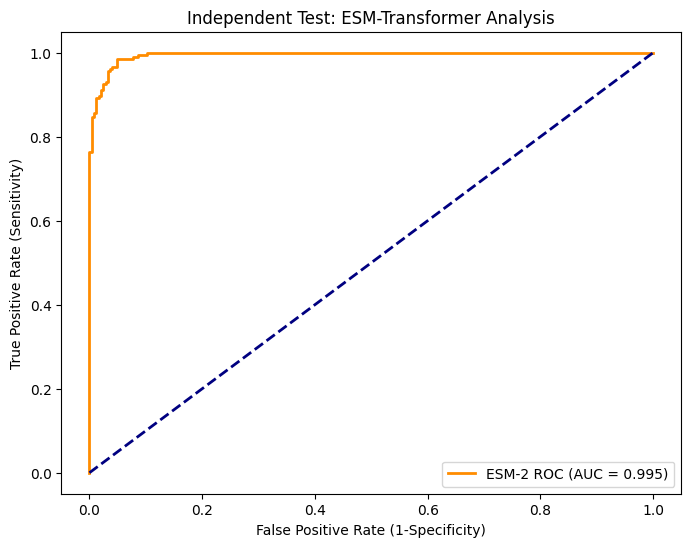


✅ Independent test data saved successfully.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# 2. Dataset Loading Function
def parse_fasta(path):
    if not os.path.exists(path):
        print(f"❌ Error: {path} not found!")
        return []
    seqs = []
    with open(path, 'r') as f:
        current = ""
        for line in f:
            if line.startswith(">"):
                if current: seqs.append(current)
                current = ""
            else: current += line.strip()
        if current: seqs.append(current)
    return seqs

# Files check and load
thermo_seqs = parse_fasta('0.6thermo.fasta')
non_thermo_seqs = parse_fasta('0.6 non thermo.fasta')

X = thermo_seqs + non_thermo_seqs
y = [1]*len(thermo_seqs) + [0]*len(non_thermo_seqs)

# 90% Training, 10% Independent Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# 3. ESM Tokenizer & Dataset
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ProteinDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs = seqs
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        # Tokenizing each sequence on the fly
        encoding = tokenizer(self.seqs[idx], padding='max_length', truncation=True, max_length=512, return_tensors="pt")
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_loader = DataLoader(ProteinDataset(X_train, y_train), batch_size=8, shuffle=True)
test_loader = DataLoader(ProteinDataset(X_test, y_test), batch_size=8)

# 4. ESM Transformer Model
class ESMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.esm = EsmModel.from_pretrained(model_name)
        # 320 is the hidden size for esm2_t6_8M
        self.classifier = nn.Sequential(
            nn.Linear(320, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling across the sequence length
        pooled_output = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(pooled_output)

model = ESMClassifier().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.BCELoss()

# 5. Training Loop
print("\n🚀 Training ESM-Transformer...")
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, mask).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 | Training Loss: {total_loss/len(train_loader):.4f}")

# 6. Comprehensive Independent Evaluation
print("\n🧪 Running Independent Testing...")
model.eval()
y_probs, y_true_list = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels']
        outputs = model(input_ids, mask).squeeze()
        # Handle cases where batch might be size 1
        if outputs.dim() == 0: outputs = outputs.unsqueeze(0)
        y_probs.extend(outputs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

y_true = np.array(y_true_list)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# --- Metric Calculations ---
f1 = f1_score(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
ba = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
prec = precision_score(y_true, y_pred)
sens = recall_score(y_true, y_pred) # Sensitivity
cm = confusion_matrix(y_true, y_pred)

# Specificity & NPV
spec = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
npv = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 7. Final Independent Test Report Print
print("\n" + "="*60)
print("     ESM-TRANSFORMER INDEPENDENT TEST RESULTS")
print("="*60)
print(f" F1-SCORE:         {f1*100:.6f}%")
print(f"Accuracy:           {acc*100:.6f}%")
print(f"ROC AUC:            {roc_auc:.6f}")
print(f"MCC Score:          {mcc:.6f}")
print("-" * 40)
print(f"Sensitivity (Sn):   {sens*100:.6f}%")
print(f"Specificity (Sp):   {spec*100:.6f}%")
print(f"Precision (Pr):     {prec*100:.6f}%")
print(f"NPV:                {npv*100:.6f}%")
print(f"Balanced Acc:       {ba*100:.6f}%")
print("-" * 60)
print(f"Confusion Matrix:\n{cm}")
print("="*60)

# 8. ROC Curve Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ESM-2 ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Independent Test: ESM-Transformer Analysis')
plt.legend(loc="lower right")
plt.show()

# 9. Save Data for Comparison
np.save('transformer_esm_fpr.npy', fpr)
np.save('transformer_esm_tpr.npy', tpr)
print("\n✅ Independent test data saved successfully.")

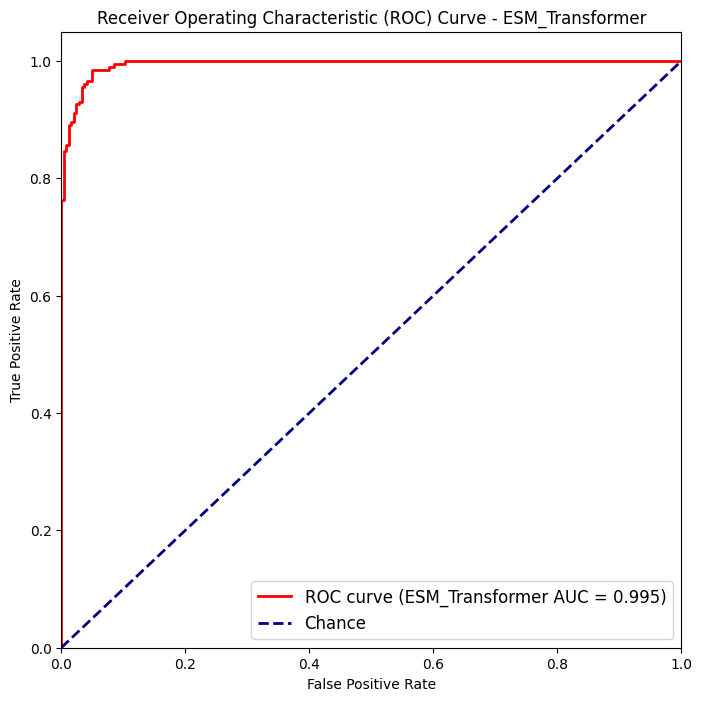

AUC for ESM_Transformer model: 0.9948


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Predicted probabilities hasil karein
# (Note: y_probs hamare ESM_Transformer ke outputs hain jo testing loop mein nikalay gaye thay)
esm_probs = np.array(y_probs)

# 2. ROC AUC calculate karein (y_true actual labels hain)
esm_auc = auc(fpr, tpr)

# 3. Compute ROC Curve (Ye variables pehle hi Metric Calculations section mein maujood hain)
# fpr, tpr, _ = roc_curve(y_true, esm_probs)

# 4. Plot ROC Curve (As per your requested style)
plt.figure(figsize=(8, 8))

# Plotting the ESM_Transformer Curve
plt.plot(fpr, tpr, color='red', lw=2, label='ROC curve (ESM_Transformer AUC = %0.3f)' % esm_auc)

# Chance line (Diagonal)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Chance")

# Plot ki settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - ESM_Transformer')
plt.legend(loc="lower right", fontsize=12)
plt.show()

# 5. Print AUC
print("AUC for ESM_Transformer model: %.4f" % esm_auc)

In [ ]:
# Transformer File ke aakhir mein ye add karein:
np.save('transformer_fpr.npy', fpr)
np.save('transformer_tpr.npy', tpr)
np.save('transformer_auc.npy', np.array([roc_auc]))
print("✅ Transformer ROC data saved as .npy files")

# File download karne ke liye (Optional):
from google.colab import files
files.download('transformer_fpr.npy')
files.download('transformer_tpr.npy')
files.download('transformer_auc.npy')

✅ Transformer ROC data saved as .npy files


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training ESM_Transformer for Accuracy Goal...
Epoch 1/15 | Training Loss: 0.4778
Epoch 2/15 | Training Loss: 0.3156
Epoch 3/15 | Training Loss: 0.2445
Epoch 4/15 | Training Loss: 0.2158
Epoch 5/15 | Training Loss: 0.1881
Epoch 6/15 | Training Loss: 0.1679
Epoch 7/15 | Training Loss: 0.1493
Epoch 8/15 | Training Loss: 0.1389
Epoch 9/15 | Training Loss: 0.1240
Epoch 10/15 | Training Loss: 0.1151
Epoch 11/15 | Training Loss: 0.1225
Epoch 12/15 | Training Loss: 0.1023
Epoch 13/15 | Training Loss: 0.1086
Epoch 14/15 | Training Loss: 0.0943
Epoch 15/15 | Training Loss: 0.0869

Running Independent Testing...

     ESM_TRANSFORMER INDEPENDENT TEST RESULTS
Accuracy:           95.100223%
Balanced Accuracy:  95.223089%
MCC Score:          0.902082
F1-Score:           94.711538%
Precision:          92.924528%
Sensitivity:        96.568627%
Specificity:        93.877551%
NPV:                97.046414%
ROC AUC:            0.976951
--------------------------------------------------
Confusion Matrix:


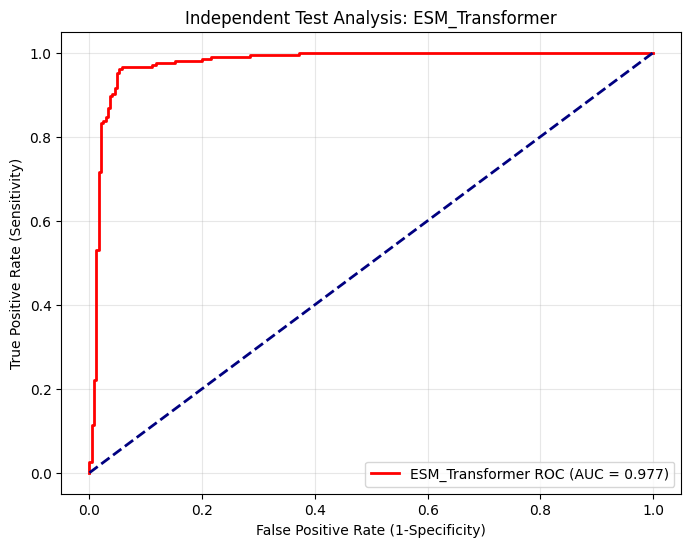


Model saved as ESM_Transformer_HighAcc.pth


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

# 1. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Dataset Parser
def parse_fasta(path):
    seqs = []
    try:
        with open(path, 'r') as f:
            current = ""
            for line in f:
                if line.startswith(">"):
                    if current: seqs.append(current)
                    current = ""
                else: current += line.strip()
            if current: seqs.append(current)
        return seqs
    except FileNotFoundError:
        print(f"Error: {path} not found!")
        return []

# Data Loading
thermo_all = parse_fasta('0.6thermo.fasta')
non_thermo_all = parse_fasta('0.6 non thermo.fasta')

# Independent Test Split (10% for Independent Testing)
split_idx_t = int(len(thermo_all) * 0.9)
split_idx_nt = int(len(non_thermo_all) * 0.9)

X_train_raw = thermo_all[:split_idx_t] + non_thermo_all[:split_idx_nt]
y_train_raw = [1]*len(thermo_all[:split_idx_t]) + [0]*len(non_thermo_all[:split_idx_nt])

X_independent = thermo_all[split_idx_t:] + non_thermo_all[split_idx_nt:]
y_independent = [1]*len(thermo_all[split_idx_t:]) + [0]*len(non_thermo_all[split_idx_nt:])

class ProteinDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs = seqs
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        encoding = tokenizer(self.seqs[idx], padding='max_length', truncation=True, max_length=512, return_tensors="pt")
        return {
            'ids': encoding['input_ids'].squeeze(0),
            'mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_loader = DataLoader(ProteinDataset(X_train_raw, y_train_raw), batch_size=4, shuffle=True)
indep_loader = DataLoader(ProteinDataset(X_independent, y_independent), batch_size=4)

# 3. Model Architecture - ESM_Transformer
class ESM_Transformer(nn.Module):
    def __init__(self):
        super(ESM_Transformer, self).__init__()
        self.esm = EsmModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(320, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, ids, mask):
        outputs = self.esm(input_ids=ids, attention_mask=mask)
        pooled = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(pooled)

model = ESM_Transformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=7e-6)
criterion = nn.BCELoss()

# 4. Training Loop
print("Training ESM_Transformer for Accuracy Goal...")
model.train()
for epoch in range(15):
    total_loss = 0
    for batch in train_loader:
        ids, mask, labels = batch['ids'].to(device), batch['mask'].to(device), batch['labels'].to(device)
        optimizer.zero_grad()
        # Using .view(-1) to handle batch consistency
        outputs = model(ids, mask).view(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/15 | Training Loss: {total_loss/len(train_loader):.4f}")

# 5. Independent Testing (FIXED ERROR SECTION)
print("\nRunning Independent Testing...")
model.eval()
y_probs, y_true_list = [], []

with torch.no_grad():
    for batch in indep_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['labels']

        # .view(-1) ensures the output is always a 1D array even if batch size is 1
        outputs = model(ids, mask).view(-1)

        y_probs.extend(outputs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

y_true = np.array(y_true_list)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# --- Metric Calculations ---
acc = accuracy_score(y_true, y_pred)
ba = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
sens = recall_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
spec = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
npv = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 6. Final Report Print
print("\n" + "="*50)
print("     ESM_TRANSFORMER INDEPENDENT TEST RESULTS")
print("="*50)
print(f"Accuracy:           {acc*100:.6f}%")
print(f"Balanced Accuracy:  {ba*100:.6f}%")
print(f"MCC Score:          {mcc:.6f}")
print(f"F1-Score:           {f1*100:.6f}%")
print(f"Precision:          {prec*100:.6f}%")
print(f"Sensitivity:        {sens*100:.6f}%")
print(f"Specificity:        {spec*100:.6f}%")
print(f"NPV:                {npv*100:.6f}%")
print(f"ROC AUC:            {roc_auc:.6f}")
print("-"*50)
print(f"Confusion Matrix:\n{cm}")
print("="*50)

# 7. Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ESM_Transformer ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Independent Test Analysis: ESM_Transformer')
plt.legend(loc="lower right")
plt.show()

# Save Model
torch.save(model.state_dict(), "ESM_Transformer_HighAcc.pth")
print("\nModel saved as ESM_Transformer_HighAcc.pth")